# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv). 

### Step 3. Assign it to a variable called chipo.

In [3]:
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"

chipo = pd.read_csv(url, sep="\t")

### Step 4. See the first 10 entries

In [4]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

Text(0, 0.5, 'Quantity')

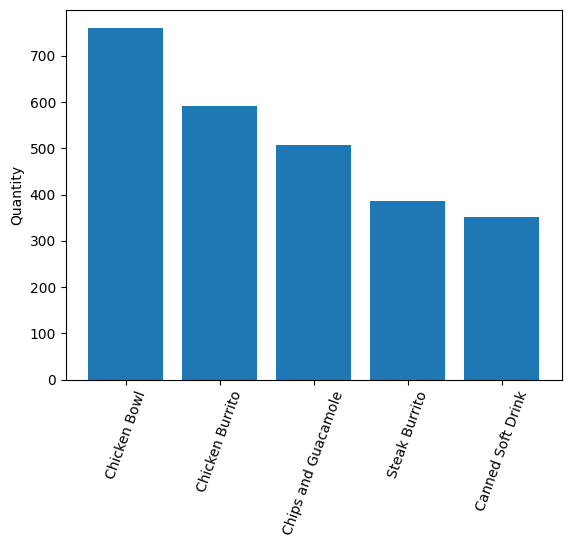

In [19]:
top5 = chipo.groupby("item_name")["quantity"].sum().sort_values(ascending=False).head(5)

x_items = top5.index.values
y_quantity = top5.values

plt.bar(x_items, y_quantity)
plt.xticks(rotation=70)
plt.ylabel("Quantity")

In [20]:
top5

item_name
Chicken Bowl           761
Chicken Burrito        591
Chips and Guacamole    506
Steak Burrito          386
Canned Soft Drink      351
Name: quantity, dtype: int64

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

In [8]:
chipo.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


In [9]:
#Numero de artículos por precio de pedido.

## Normalizar la columna de precio.
chipo["item_price"] = chipo["item_price"].str.replace("$", "").astype("float")

# Agrupar por pedido.
##total_ord_price = chipo.groupby("order_id")["item_price"].sum() ##MEJORADO

# Sumar total del pedido y cantidad de artículos.
##total_ord_items = chipo.groupby("order_id")["quantity"].sum() ##MEJORADO

orders = chipo.groupby("order_id").agg({
    "item_price": "sum",
    "quantity": "sum"
})

In [10]:
orders

,item_price,quantity
order_id,,
1,11.56,4
2,16.98,2
3,12.67,2
4,21.00,2
5,13.70,2
...,...,...
1830,23.00,2
1831,12.90,3
1832,13.20,2


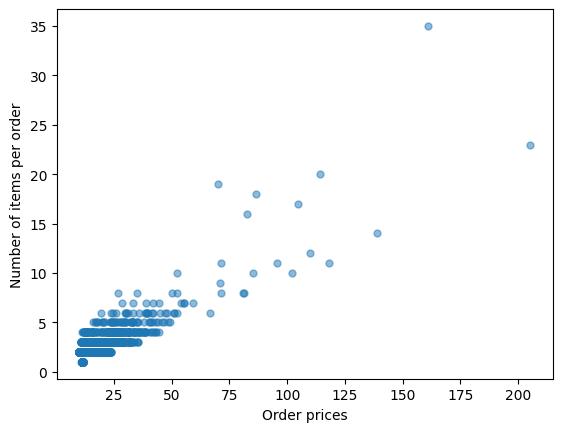

In [11]:
plt.xlabel("Order prices")
plt.ylabel("Number of items per order")

#plt.scatter(total_ord_price, total_ord_items)
plt.scatter(orders["item_price"], orders["quantity"], s=25, alpha=0.5)